In [1]:
import pandas as pd
df = pd.read_csv("../data/sample_emails.csv")
df.head()

,id,sender,subject,body,priority,label
0,1,hr@company.com,Offer Letter - Please Sign,"Dear Candidate, Congratulations! Please sign a...",high,important
1,2,noreply@shopping.com,Big Billion Sale is Live,Flat 70% OFF on electronics. Limited period of...,low,promotion
2,3,alerts@mybank.com,Unusual Login Attempt,We detected a login attempt to your account fr...,high,security
3,4,newsletter@blog.com,Weekly Tech Newsletter,"In this week's edition, learn about AI agents,...",low,newsletter
4,5,friend123@gmail.com,Coffee this weekend?,"Hey, long time no see! Are you free this weeke...",medium,personal


In [2]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8 entries, 0 to 7
Data columns (total 6 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   id        8 non-null      int64 
 1   sender    8 non-null      object
 2   subject   8 non-null      object
 3   body      8 non-null      object
 4   priority  8 non-null      object
 5   label     8 non-null      object
dtypes: int64(1), object(5)
memory usage: 516.0+ bytes


1.Handle Missing Values & Clean Text
2.Create a Combined Text Column (Subject + Body)
3.Simple Filtering Examples

In [3]:
df.describe(include="all")

,id,sender,subject,body,priority,label
count,8.00000,8,8,8,8,8
unique,NaN,8,8,8,3,7
top,NaN,hr@company.com,Offer Letter - Please Sign,"Dear Candidate, Congratulations! Please sign a...",high,work
freq,NaN,1,1,1,4,2
mean,4.50000,NaN,NaN,NaN,NaN,NaN
std,2.44949,NaN,NaN,NaN,NaN,NaN
min,1.00000,NaN,NaN,NaN,NaN,NaN
25%,2.75000,NaN,NaN,NaN,NaN,NaN
50%,4.50000,NaN,NaN,NaN,NaN,NaN
75%,6.25000,NaN,NaN,NaN,NaN,NaN


In [4]:
df["label"].value_counts()

label
work          2
promotion     1
important     1
security      1
newsletter    1
personal      1
spam          1
Name: count, dtype: int64

In [5]:
df.fillna("")

,id,sender,subject,body,priority,label
0,1,hr@company.com,Offer Letter - Please Sign,"Dear Candidate, Congratulations! Please sign a...",high,important
1,2,noreply@shopping.com,Big Billion Sale is Live,Flat 70% OFF on electronics. Limited period of...,low,promotion
2,3,alerts@mybank.com,Unusual Login Attempt,We detected a login attempt to your account fr...,high,security
3,4,newsletter@blog.com,Weekly Tech Newsletter,"In this week's edition, learn about AI agents,...",low,newsletter
4,5,friend123@gmail.com,Coffee this weekend?,"Hey, long time no see! Are you free this weeke...",medium,personal
5,6,spam@strange-domain.ru,"You won $1,000,000!!!",Click here to claim your lottery now. Do not s...,high,spam
6,7,manager@company.com,Project Update Required,Please share the status update of your project...,high,work
7,8,training@lms.com,Reminder: Complete Mandatory Training,Your mandatory security awareness training is ...,medium,work


In [6]:
df = df.fillna("")
df['subject'] = df['subject'].str.lower().str.strip()
df['body'] = df['body'].str.lower().str.strip()
print(df)

   id                  sender                                subject  \
0   1          hr@company.com             offer letter - please sign   
1   2    noreply@shopping.com               big billion sale is live   
2   3       alerts@mybank.com                  unusual login attempt   
3   4     newsletter@blog.com                 weekly tech newsletter   
4   5     friend123@gmail.com                   coffee this weekend?   
5   6  spam@strange-domain.ru                  you won $1,000,000!!!   
6   7     manager@company.com                project update required   
7   8        training@lms.com  reminder: complete mandatory training   

                                                body priority       label  
0  dear candidate, congratulations! please sign a...     high   important  
1  flat 70% off on electronics. limited period of...      low   promotion  
2  we detected a login attempt to your account fr...     high    security  
3  in this week's edition, learn about ai agent

In [7]:
df['combined'] = df['subject'] + " " + df['body']
print(df)

   id                  sender                                subject  \
0   1          hr@company.com             offer letter - please sign   
1   2    noreply@shopping.com               big billion sale is live   
2   3       alerts@mybank.com                  unusual login attempt   
3   4     newsletter@blog.com                 weekly tech newsletter   
4   5     friend123@gmail.com                   coffee this weekend?   
5   6  spam@strange-domain.ru                  you won $1,000,000!!!   
6   7     manager@company.com                project update required   
7   8        training@lms.com  reminder: complete mandatory training   

                                                body priority       label  \
0  dear candidate, congratulations! please sign a...     high   important   
1  flat 70% off on electronics. limited period of...      low   promotion   
2  we detected a login attempt to your account fr...     high    security   
3  in this week's edition, learn about ai a

In [8]:
offer_only = df[df['combined'].str.contains("offer")]
print(df)
print("\nOffer Messages:")
print(offer_only)

   id                  sender                                subject  \
0   1          hr@company.com             offer letter - please sign   
1   2    noreply@shopping.com               big billion sale is live   
2   3       alerts@mybank.com                  unusual login attempt   
3   4     newsletter@blog.com                 weekly tech newsletter   
4   5     friend123@gmail.com                   coffee this weekend?   
5   6  spam@strange-domain.ru                  you won $1,000,000!!!   
6   7     manager@company.com                project update required   
7   8        training@lms.com  reminder: complete mandatory training   

                                                body priority       label  \
0  dear candidate, congratulations! please sign a...     high   important   
1  flat 70% off on electronics. limited period of...      low   promotion   
2  we detected a login attempt to your account fr...     high    security   
3  in this week's edition, learn about ai a

In [9]:
important_only = df[df['label'].str.contains("important")]
print(important_only)

   id          sender                     subject  \
0   1  hr@company.com  offer letter - please sign   

                                                body priority      label  \
0  dear candidate, congratulations! please sign a...     high  important   

                                            combined  
0  offer letter - please sign dear candidate, con...  


In [10]:
df.shape

(8, 7)

In [11]:
df.isnull().sum()

id          0
sender      0
subject     0
body        0
priority    0
label       0
combined    0
dtype: int64

In [12]:
print(df['subject'][0])

offer letter - please sign


In [13]:
df['priority'].value_counts()

priority
high      4
low       2
medium    2
Name: count, dtype: int64

In [14]:
df.columns

Index(['id', 'sender', 'subject', 'body', 'priority', 'label', 'combined'], dtype='object')

In [15]:
df['clean_text'] = df['body'].str.lower().str.replace('[^a-zA-Z]',"",regex=True)
df[['body','clean_text']].head()

,body,clean_text
0,"dear candidate, congratulations! please sign a...",dearcandidatecongratulationspleasesignanduploa...
1,flat 70% off on electronics. limited period of...,flatoffonelectronicslimitedperiodoffervisitour...
2,we detected a login attempt to your account fr...,wedetectedaloginattempttoyouraccountfromanewde...
3,"in this week's edition, learn about ai agents,...",inthisweekseditionlearnaboutaiagentslanggrapha...
4,"hey, long time no see! are you free this weeke...",heylongtimenoseeareyoufreethisweekendforcoffee


In [16]:
from collections import Counter

all_words = " ".join(df['clean_text']).split()
word_freq = Counter(all_words)
word_freq.most_common(3)

[('dearcandidatecongratulationspleasesignanduploadyourofferletterbytodayevening',
  1),
 ('flatoffonelectronicslimitedperiodoffervisitourstorenow', 1),
 ('wedetectedaloginattempttoyouraccountfromanewdeviceifthiswasnotyoupleaseresetyourpassword',
  1)]

In [17]:
all_words_text = "".join(df['clean_text'])

In [18]:
df.columns

Index(['id', 'sender', 'subject', 'body', 'priority', 'label', 'combined',
       'clean_text'],
      dtype='object')

In [19]:
df['clean_text'] = df['body'].str.lower().str.replace('[^a-zA-Z]','',regex=True)
df[['body','clean_text']].head()

,body,clean_text
0,"dear candidate, congratulations! please sign a...",dearcandidatecongratulationspleasesignanduploa...
1,flat 70% off on electronics. limited period of...,flatoffonelectronicslimitedperiodoffervisitour...
2,we detected a login attempt to your account fr...,wedetectedaloginattempttoyouraccountfromanewde...
3,"in this week's edition, learn about ai agents,...",inthisweekseditionlearnaboutaiagentslanggrapha...
4,"hey, long time no see! are you free this weeke...",heylongtimenoseeareyoufreethisweekendforcoffee


In [20]:
all_words_text = " ".join(df['clean_text'])

In [21]:
words = all_words_text.split()

In [22]:
len(words)

8

In [24]:
import nltk
nltk.download('stopwords')
from nltk.corpus import stopwords

stop_words = set(stopwords.words('english'))
filtered_words = [w for w in words if w not in stop_words]

[nltk_data] Downloading package stopwords to C:\Users\PC-
[nltk_data]     LENOVO\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [25]:
import nltk
nltk.download('stopwords')
from nltk.corpus import stopwords

stop_words = set(stopwords.words('english'))
filtered_words = [w for w in words if w not in stop_words]

[nltk_data] Downloading package stopwords to C:\Users\PC-
[nltk_data]     LENOVO\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [26]:
# Without NLTK 
["please", "approve","the","project","status","update","urgently"]

#With NLTK
["approv","project","status","updat","urgent"]

['approv', 'project', 'status', 'updat', 'urgent']

In [27]:

import pandas as pd
df=pd.read_csv("../data/sample_emails.csv")

In [28]:
import nltk
nltk.download('stopwords')

[nltk_data] Downloading package stopwords to C:\Users\PC-
[nltk_data]     LENOVO\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


True

In [29]:
df.head(3)

,id,sender,subject,body,priority,label
0,1,hr@company.com,Offer Letter - Please Sign,"Dear Candidate, Congratulations! Please sign a...",high,important
1,2,noreply@shopping.com,Big Billion Sale is Live,Flat 70% OFF on electronics. Limited period of...,low,promotion
2,3,alerts@mybank.com,Unusual Login Attempt,We detected a login attempt to your account fr...,high,security


In [30]:
pd.DataFrame(word_freq.most_common(20), columns=["word", "count"])

,word,count
0,dearcandidatecongratulationspleasesignanduploa...,1
1,flatoffonelectronicslimitedperiodoffervisitour...,1
2,wedetectedaloginattempttoyouraccountfromanewde...,1
3,inthisweekseditionlearnaboutaiagentslanggrapha...,1
4,heylongtimenoseeareyoufreethisweekendforcoffee,1
5,clickheretoclaimyourlotterynowdonotsharethiswi...,1
6,pleasesharethestatusupdateofyourprojectbeforep...,1
7,yourmandatorysecurityawarenesstrainingisduetom...,1


Stemming
Lemmatization
Keyword extraction
word frequency count
spam keyword detection rule
types of nlkt method


task
Visualize category counts using a Bar Chart
Write 2–3 bullet points explaining:

Why you chose that new category?

How is the rule detecting it?
Add a pie chart for categories

Extract top 5 keywords per category

Highlight emails with multiple category matches

In [33]:
import re

df['clean_text'] = (
    df['body']
    .str.lower()                              
    .str.replace(r'[^a-z\s]', '', regex=True) 
    .str.replace(r'\s+', ' ', regex=True)     
    .str.strip()
)
print(df['clean_text'])

0    dear candidate congratulations please sign and...
1    flat off on electronics limited period offer v...
2    we detected a login attempt to your account fr...
3    in this weeks edition learn about ai agents la...
4    hey long time no see are you free this weekend...
5    click here to claim your lottery now do not sh...
6    please share the status update of your project...
7    your mandatory security awareness training is ...
Name: clean_text, dtype: object


In [34]:
import nltk

nltk.download('punkt')
nltk.download('stopwords')

[nltk_data] Downloading package punkt to C:\Users\PC-
[nltk_data]     LENOVO\AppData\Roaming\nltk_data...
[nltk_data]   Unzipping tokenizers\punkt.zip.
[nltk_data] Downloading package stopwords to C:\Users\PC-
[nltk_data]     LENOVO\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


True

In [36]:
from nltk.tokenize import wordpunct_tokenize

def remove_stopwords(text):
    if not isinstance(text, str):
        return ""
    words = wordpunct_tokenize(text.lower())
    return " ".join([w for w in words if w.isalpha() and w not in stop_words])

df['clean_text'] = df['body'].fillna("").apply(remove_stopwords)

In [37]:
print(df['clean_text'])

0    dear candidate congratulations please sign upl...
1    flat electronics limited period offer visit store
2    detected login attempt account new device plea...
3               week edition learn ai agents langgraph
4                hey long time see free weekend coffee
5                     click claim lottery share anyone
6          please share status update project pm today
7    mandatory security awareness training due tomo...
Name: clean_text, dtype: object


In [38]:
df['clean_text'].head(3)

0    dear candidate congratulations please sign upl...
1    flat electronics limited period offer visit store
2    detected login attempt account new device plea...
Name: clean_text, dtype: object

In [39]:
from collections import Counter

# Combine 
all_words = " ".join(df['clean_text']).split()

# Count word frequency
word_freq = Counter(all_words)

# Convert to DataFrame
word_freq_df = (
    pd.DataFrame(word_freq.items(), columns=['Word', 'Frequency'])
    .sort_values(by='Frequency', ascending=False)
)

# Show top 10 words
word_freq_df.head(10)

,Word,Frequency
3,please,3
6,offer,2
8,today,2
40,share,2
2,congratulations,1
1,candidate,1
5,upload,1
4,sign,1
7,letter,1
9,evening,1


In [40]:
from collections import Counter
all_words = " ".join(df['clean_text']).split()
word_freq = Counter(all_words)
word_freq_df = (pd.DataFrame(word_freq.items(), columns=['Word', 'Frequency'])
                .sort_values(by='Frequency', ascending=False))
word_freq_df.head()

,Word,Frequency
3,please,3
6,offer,2
8,today,2
40,share,2
2,congratulations,1


In [41]:
from nltk.stem import PorterStemmer

In [42]:
ps=PorterStemmer()
df['stemmed_text'] = df['clean_text'].apply(
    lambda x: "".join(ps.stem(w) for w in x.split())
)
print(df[['clean_text','stemmed_text']].head())

                                          clean_text  \
0  dear candidate congratulations please sign upl...   
1  flat electronics limited period offer visit store   
2  detected login attempt account new device plea...   
3             week edition learn ai agents langgraph   
4              hey long time see free weekend coffee   

                                        stemmed_text  
0  dearcandidcongratulpleassignuploadofferlettert...  
1             flatelectronlimitperiodoffervisitstore  
2  detectloginattemptaccountnewdevicpleasresetpas...  
3                      weekeditlearnaiagentlanggraph  
4                     heylongtimeseefreeweekendcoffe  


In [43]:
from nltk.stem import WordNetLemmatizer
lemmatizer = WordNetLemmatizer()
df['lemmatized_text']=df['clean_text'].apply(
    lambda x:"".join(lemmatizer.lemmatize(word) for word in x.split())

)
df[['clean_text','lemmatized_text']].head()

LookupError: 
**********************************************************************
  Resource [93mwordnet[0m not found.
  Please use the NLTK Downloader to obtain the resource:

  [31m>>> import nltk
  >>> nltk.download('wordnet')
  [0m
  For more information see: https://www.nltk.org/data.html

  Attempted to load [93mcorpora/wordnet[0m

  Searched in:
    - 'C:\\Users\\PC-LENOVO/nltk_data'
    - 'c:\\Program Files\\Python313\\nltk_data'
    - 'c:\\Program Files\\Python313\\share\\nltk_data'
    - 'c:\\Program Files\\Python313\\lib\\nltk_data'
    - 'C:\\Users\\PC-LENOVO\\AppData\\Roaming\\nltk_data'
    - 'C:\\nltk_data'
    - 'D:\\nltk_data'
    - 'E:\\nltk_data'
**********************************************************************


In [ ]:
import nltk
nltk.download('wordnet')
nltk.download('omw-1.4')

[nltk_data] Downloading package wordnet to C:\Users\PC-
[nltk_data]     LENOVO\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package omw-1.4 to C:\Users\PC-
[nltk_data]     LENOVO\AppData\Roaming\nltk_data...


In [45]:
#Keyword_Extraction
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf = TfidfVectorizer()
X = tfidf.fit_transform(df['clean_text'])

keywords = tfidf.get_feature_names_out()
print(keywords[:15])
['account' 'agents' 'ai' 'anyone' 'attempt' 'awareness' 'candidate'
 'claim' 'click' 'coffee' 'congratulations' 'dear' 'detected' 'device'
 'due']

['account' 'agents' 'ai' 'anyone' 'attempt' 'awareness' 'candidate'
 'claim' 'click' 'coffee' 'congratulations' 'dear' 'detected' 'device'
 'due']


['accountagentsaianyoneattemptawarenesscandidateclaimclickcoffeecongratulationsdeardetecteddevicedue']

In [46]:
spam_words = [
    'click', 'claim', 'free', 'offer', 'lottery',
    'winner', 'congratulations', 'prize', 'share'
]

df['is_spam'] = df['clean_text'].apply(
    lambda text: any(word in text.split() for word in spam_words)
)

df[['clean_text', 'is_spam']]

,clean_text,is_spam
0,dear candidate congratulations please sign upl...,True
1,flat electronics limited period offer visit store,True
2,detected login attempt account new device plea...,False
3,week edition learn ai agents langgraph,False
4,hey long time see free weekend coffee,True
5,click claim lottery share anyone,True
6,please share status update project pm today,True
7,mandatory security awareness training due tomo...,False


In [47]:
def detect_spam(text):
    count = sum(word in text.split() for word in spam_words)
    return count >= 2 # spam only if 2+ spam words

df['is_spam_improved'] = df['clean_text'].apply(detect_spam)
df[['clean_text', 'is_spam_improved']]

,clean_text,is_spam_improved
0,dear candidate congratulations please sign upl...,True
1,flat electronics limited period offer visit store,False
2,detected login attempt account new device plea...,False
3,week edition learn ai agents langgraph,False
4,hey long time see free weekend coffee,False
5,click claim lottery share anyone,True
6,please share status update project pm today,False
7,mandatory security awareness training due tomo...,False


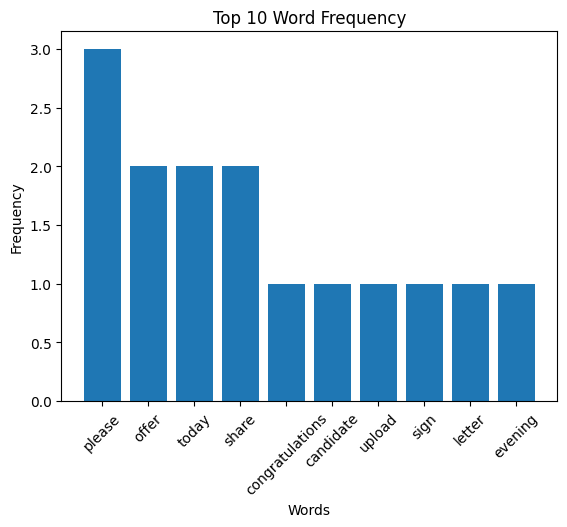

In [48]:
import matplotlib.pyplot as plt

# Top 10 words
top_words = word_freq_df.head(10)

plt.figure()
plt.bar(top_words['Word'], top_words['Frequency'])
plt.xlabel('Words')
plt.ylabel('Frequency')
plt.title('Top 10 Word Frequency')
plt.xticks(rotation=45)
plt.show()

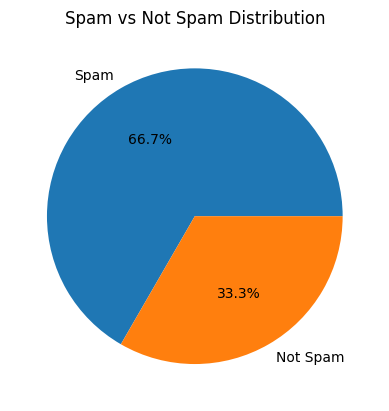

In [49]:
spam_counts1 = df['is_spam_improved'].head(3).value_counts()

plt.figure()
plt.pie(
    spam_counts1,
    labels=['Spam', 'Not Spam'],
    autopct='%1.1f%%'
)
plt.title('Spam vs Not Spam Distribution')
plt.show()

In [50]:
import matplotlib.pyplot as plt

# Sort categories by frequency
items = sorted(cat_counter.items(), key=lambda x: x[1], reverse=True)
labels = [x[0] for x in items]
values = [x[1] for x in items]

plt.figure(figsize=(9, 4.5))
bars = plt.bar(labels, values, edgecolor='black')

plt.title("Email Category Frequency")
plt.xlabel("Category")
plt.ylabel("Count")

# Label each bar with its count
for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        height + 0.1,
        str(int(height)),
        ha='center',
        va='bottom'
    )

plt.tight_layout()
plt.show()


NameError: name 'cat_counter' is not defined

In [51]:
items = sorted(cat_counter.items(), key=lambda x: x[1], reverse=True)
cats = [c for c, _ in items]
vals = [v for _, v in items]

plt.pie(vals, labels=cats, autopct="%1.1f%%", startangle=90)
plt.title("Category Distribution")
plt.axis("equal")
plt.show()

NameError: name 'cat_counter' is not defined